In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

In [17]:
pd.set_option('display.max_columns', None)

In [18]:
# def load_and_impute(file_path, target_col):
#     df = pd.read_csv(file_path)
#     print("Data Shape:", df.shape)

#     print("\nFirst 5 rows:")
#     print(df.head())

#     print("\nTarget Class Distribution:")
#     print(df[target_col].value_counts().sort_index())

#     print('Missing values: ',df.isnull().sum())
#     df.fillna(df.mean(numeric_only=True), inplace=True)

#     X = df.drop(columns=[target_col]).values
#     y = df[target_col].values
    
#     return X, y

In [19]:
def load_and_impute(file_path, target_col):
    df = pd.read_csv(file_path)
    
    num_duplicates = df.duplicated().sum()
    print(f"Original shape: {df.shape}")
    print(f"Duplicate rows found: {num_duplicates}")
    
    if num_duplicates > 0:
        df.drop_duplicates(inplace=True)
        print(f"Shape after dropping duplicates: {df.shape}")
    
    df.fillna(df.mean(numeric_only=True), inplace=True)

    X = df.drop(columns=[target_col]).values
    y = df[target_col].values
    
    return X, y

In [20]:
df_path = 'heart.csv'
target_col = 'target'
X, y = load_and_impute(df_path, target_col)

Original shape: (1025, 14)
Duplicate rows found: 723
Shape after dropping duplicates: (302, 14)


In [21]:
def train_test_split(X, y, train_ratio=0.8, val_ratio=0.1, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    indices = np.random.permutation(n_samples)

    train_idx = indices[:int(train_ratio*n_samples)]
    val_idx = indices[int(train_ratio*n_samples) : int((train_ratio+val_ratio)*n_samples)]
    test_idx = indices[int((train_ratio+val_ratio)*n_samples):]

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx]


X_train, y_train, X_val, y_val, X_test, y_test = train_test_split(X, y, train_ratio=0.8, val_ratio=0.1, random_state=42)

In [22]:
class standardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1

    def transform(self, X):
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    

scaler = standardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [23]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.value = value
        self.right = right
        self.left = left

In [24]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None
    
    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(self.n_features, X.shape[1])
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feat = X.shape
        n_labels = len(np.unique(y))

        if (depth >= self.max_depth or n_labels==1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        feat_idx = np.random.choice(n_feat, self.n_features, replace=False)
        best_feat, best_thresh = self._best_split(X, y, feat_idx)

        if best_feat is None:
            leaf_value = self.most_common_label(y)
            return Node(value=leaf_value)

        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs,:], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs,:], y[right_idxs], depth+1)

        return Node(feature_idx=best_feat, threshold=best_thresh, left=left, right=right)
    
    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for thr in thresholds:
                gain = self._information_gain(y, X_column, thr)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr

        return split_idx, split_threshold
    

    def _information_gain(self, y, X_column, threshold):
        parent_gini = self._gini(y)
        left_idxs, right_idxs = self._split(X_column, threshold)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
        
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._gini(y[left_idxs]), self._gini(y[right_idxs])

        child_gini = (n_l / n) * e_l + (n_r / n) * e_r
        ig = parent_gini - child_gini
        return ig
    

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs
    

    def _gini(self, y):
        #Gini Index: 1 - sum(p^2)
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        gini = 1 - np.sum(probabilities**2)
        return gini
    

    def _most_common_label(self, y):
        if len(y) == 0: return 0
        return np.bincount(y).argmax()
    

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
    
    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value

        if x[node.feature_idx] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

In [25]:
dt = DecisionTree(max_depth=3, n_features=5)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
acc = np.sum(y_pred == y_test) / len(y_test)
print(f"Single Tree Accuracy: {acc}")

Single Tree Accuracy: 0.7741935483870968


In [26]:
class RandomForest:
    def __init__(self, n_estimators=10, min_samples_split=2, max_depth=100, n_features=None):
        self.n_estimators = n_estimators
        self.min_samples_split = 2
        self.max_depth = max_depth
        self.n_features = n_features
        self.trees = []

    def _bootstrap_samples(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]
    
    def _most_common_label(self, y):
        return np.bincount(y).argmax()
    
    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_estimators):
            tree = DecisionTree(
                min_samples_split=self.min_samples_split,
                max_depth=self.max_depth,
                n_features=self.n_features
                )
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        y_pred = [self._most_common_label(tree_pred) for tree_pred in tree_preds]
        return np.array(y_pred)

In [27]:
def calculate_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1, [[tn, fp], [fn, tp]]    

In [28]:
def accuracy_score(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

In [29]:
def run_experiment(X_train, y_train, X_test, y_test):
    n_estimators_list = [2, 5, 10, 15, 20]
    max_depth_list = [1, 3, 5, 7, 9]
    n_features_list = [3, 7, 13]    
    results = []

    total_combos = len(n_estimators_list) * len(max_depth_list) * len(n_features_list)
    current_combo = 0

    for n_est in n_estimators_list:
        for depth in max_depth_list:
            for n_feat in n_features_list:
                current_combo += 1
                
                train_accs = []
                val_accs = []
                test_accs = []
                
                for seed in range(10):
                    np.random.seed(seed)
                    
                    clf = RandomForest(n_estimators=n_est, 
                                       max_depth=depth, 
                                       n_features=n_feat,
                                       min_samples_split=2)
                    
                    clf.fit(X_train, y_train)
                    
                    train_accs.append(calculate_metrics(y_train, clf.predict(X_train))[0])
                    val_accs.append(calculate_metrics(y_val, clf.predict(X_val))[0])
                    test_accs.append(calculate_metrics(y_test, clf.predict(X_test))[0])
                
                avg_train = np.mean(train_accs)
                avg_val = np.mean(val_accs)
                avg_test = np.mean(test_accs)
                
                results.append({
                    'n_estimators': n_est,
                    'max_depth': depth,
                    'n_features': n_feat,
                    'train_acc': avg_train,
                    'val_acc': avg_val,
                    'test_acc': avg_test
                })
                
                print(f"{current_combo}/{total_combos}: Trees={n_est}, Depth={depth}, Feats={n_feat} -> Train Acc: {avg_train:.4f} Val Acc: {avg_val:.4f} Test Acc: {avg_test:.4f}")

    best_result = max(results, key=lambda x: x['val_acc'])

    print("\n" + "="*40)
    print("BEST HYPERPARAMETERS")
    print(f"Trees: {best_result['n_estimators']}")
    print(f"Depth: {best_result['max_depth']}")
    print(f"Features: {best_result['n_features']}")
    print(f"Validation Accuracy: {best_result['val_acc']:.4f}")
    print("="*40)

    best_clf = RandomForest(n_estimators=best_result['n_estimators'],
                            max_depth=best_result['max_depth'],
                            n_features=best_result['n_features'],
                            min_samples_split=2)
    best_clf.fit(X_train, y_train)
    y_final_pred = best_clf.predict(X_test)
    
    acc, prec, rec, f1, cm = calculate_metrics(y_test, y_final_pred)
    
    print("\n---Best Model ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("Confusion Matrix:")
    print(f"TN: {cm[0][0]} | FP: {cm[0][1]}")
    print(f"FN: {cm[1][0]} | TP: {cm[1][1]}")

    plot_results(results, best_result)


def plot_results(results, best_params):
    df_res = pd.DataFrame(results)
    
    opt_depth = best_params['max_depth']
    opt_feat = best_params['n_features']
    opt_trees = best_params['n_estimators']

    print("\n" + "-" * 20)
    subset_trees = df_res[(df_res['max_depth'] == opt_depth) & (df_res['n_features'] == opt_feat)]
    subset_trees = subset_trees.sort_values(by='n_estimators') 
    print(f"rf_acc_trees = {subset_trees['val_acc'].tolist()}")

    subset_depth = df_res[(df_res['n_estimators'] == opt_trees) & (df_res['n_features'] == opt_feat)]
    subset_depth = subset_depth.sort_values(by='max_depth')
    print(f"rf_acc_depth = {subset_depth['val_acc'].tolist()}")
    
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(subset_trees['n_estimators'], subset_trees['train_acc'], label='Train', marker='o')
    plt.plot(subset_trees['n_estimators'], subset_trees['val_acc'], label='Validation', marker='o')
    plt.title(f'Effect of n_estimators\n(Depth={opt_depth}, Feats={opt_feat})')
    plt.xlabel('Number of Trees')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(subset_depth['max_depth'], subset_depth['train_acc'], label='Train', marker='o')
    plt.plot(subset_depth['max_depth'], subset_depth['val_acc'], label='Validation', marker='o')
    plt.title(f'Effect of Max Depth\n(Trees={opt_trees}, Feats={opt_feat})')
    plt.xlabel('Max Depth')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    subset_feat = df_res[(df_res['n_estimators'] == opt_trees) & (df_res['max_depth'] == opt_depth)]
    subset_feat = subset_feat.sort_values(by='n_features')
    plt.plot(subset_feat['n_features'], subset_feat['train_acc'], label='Train', marker='o')
    plt.plot(subset_feat['n_features'], subset_feat['val_acc'], label='Validation', marker='o')
    plt.plot(subset_feat['n_features'], subset_feat['test_acc'], label='Test', marker='o', linestyle='--')
    plt.title(f'Effect of n_features\n(Trees={opt_trees}, Depth={opt_depth})')
    plt.xlabel('Number of Features')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


1/75: Trees=2, Depth=1, Feats=3 -> Train Acc: 0.7237 Val Acc: 0.6800 Test Acc: 0.6806
2/75: Trees=2, Depth=1, Feats=7 -> Train Acc: 0.7436 Val Acc: 0.7433 Test Acc: 0.6806
3/75: Trees=2, Depth=1, Feats=13 -> Train Acc: 0.7402 Val Acc: 0.7767 Test Acc: 0.6548
4/75: Trees=2, Depth=3, Feats=3 -> Train Acc: 0.7743 Val Acc: 0.7067 Test Acc: 0.7613
5/75: Trees=2, Depth=3, Feats=7 -> Train Acc: 0.8087 Val Acc: 0.7300 Test Acc: 0.7323
6/75: Trees=2, Depth=3, Feats=13 -> Train Acc: 0.8203 Val Acc: 0.7533 Test Acc: 0.7548
7/75: Trees=2, Depth=5, Feats=3 -> Train Acc: 0.8402 Val Acc: 0.6833 Test Acc: 0.7161
8/75: Trees=2, Depth=5, Feats=7 -> Train Acc: 0.8685 Val Acc: 0.7333 Test Acc: 0.7419
9/75: Trees=2, Depth=5, Feats=13 -> Train Acc: 0.8651 Val Acc: 0.7033 Test Acc: 0.7323
10/75: Trees=2, Depth=7, Feats=3 -> Train Acc: 0.8730 Val Acc: 0.7000 Test Acc: 0.6774
11/75: Trees=2, Depth=7, Feats=7 -> Train Acc: 0.9104 Val Acc: 0.7200 Test Acc: 0.7097
12/75: Trees=2, Depth=7, Feats=13 -> Train Acc: 0

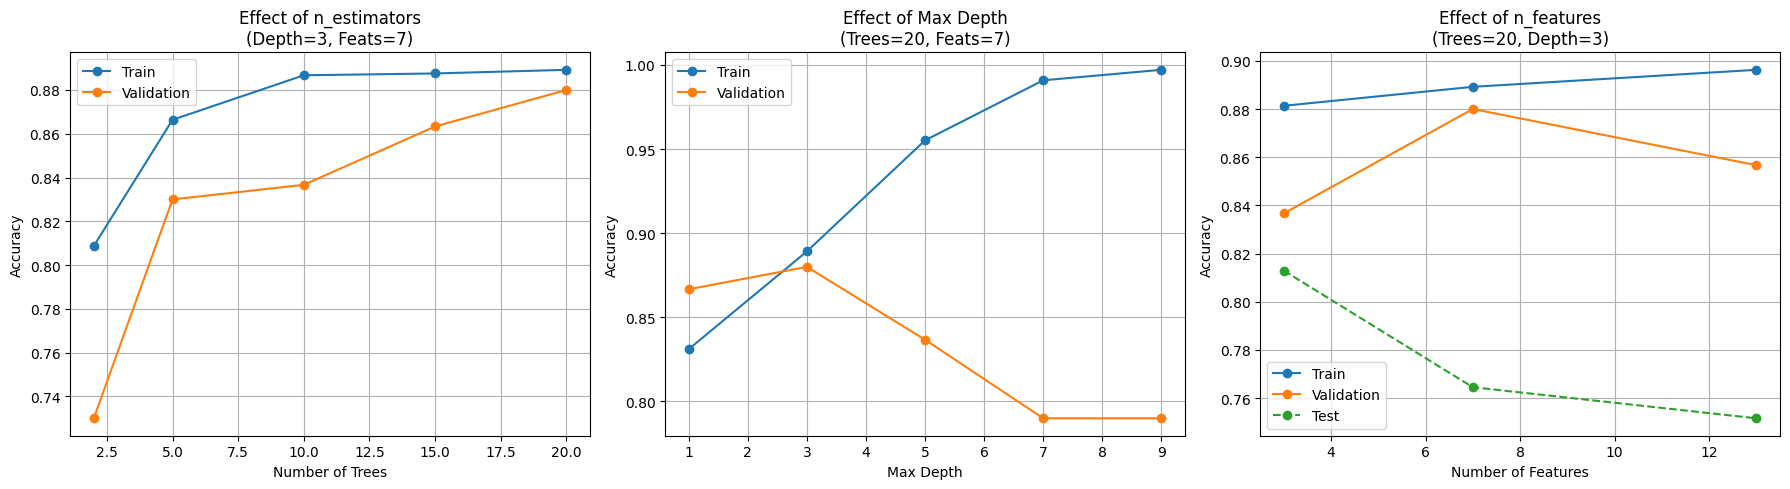

In [30]:
run_experiment(X_train, y_train, X_test, y_test)